# Medical Billing Research Project
## 03d — Model Comparison and Selection

**Loads from:** ../models/ (all saved metrics and predictions)
**Target variable:** Processing Class (Timely / Delayed)

### Objective
Compare all three models side by side across all evaluation
metrics. Select the best performing model and justify the
selection. Produce the combined ROC curve plot for the report.

In [1]:
# ============================================================
# CELL 1: LOAD ALL SAVED RESULTS
# We load the metrics and predictions saved by each
# individual model notebook. This keeps the comparison
# notebook independent — it does not refit any model,
# it only reads the saved outputs.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# ── Load metrics for all three models ────────────────────
models_dir = r'C:\2026\MedicalBillingResearch\models'

with open(f'{models_dir}\\lr_metrics.json') as f:
    lr = json.load(f)
with open(f'{models_dir}\\dt_metrics.json') as f:
    dt = json.load(f)
with open(f'{models_dir}\\rf_metrics.json') as f:
    rf = json.load(f)

# ── Load predictions for ROC curve ───────────────────────
lr_preds = pd.read_csv(f'{models_dir}\\lr_predictions.csv')
dt_preds = pd.read_csv(f'{models_dir}\\dt_predictions.csv')
rf_preds = pd.read_csv(f'{models_dir}\\rf_predictions.csv')

# ── Load variable importance ──────────────────────────────
dt_imp = pd.read_csv(
    f'{models_dir}\\dt_variable_importance.csv'
)
rf_imp = pd.read_csv(
    f'{models_dir}\\rf_variable_importance.csv'
)

print("=" * 60)
print("ALL MODEL RESULTS LOADED")
print("=" * 60)
print(f"\n  Logistic Regression metrics : loaded")
print(f"  Decision Tree metrics       : loaded")
print(f"  Random Forest metrics       : loaded")
print(f"\n  Prediction records:")
print(f"    LR  : {len(lr_preds):,}")
print(f"    DT  : {len(dt_preds):,}")
print(f"    RF  : {len(rf_preds):,}")

# ============================================================
# CELL 2: SIDE BY SIDE METRICS COMPARISON TABLE
# ============================================================

metrics_df = pd.DataFrame([lr, dt, rf])[[
    'model', 'accuracy', 'auc', 'f1_delayed',
    'precision_delayed', 'recall_delayed',
    'true_positives', 'false_negatives',
    'false_positives', 'true_negatives'
]]

print("\n" + "=" * 60)
print("MODEL COMPARISON — ALL METRICS")
print("=" * 60)
print(f"\n  {'Metric':<25} {'Log Reg':>12} "
      f"{'Dec Tree':>12} {'Rand Forest':>12}")
print(f"  {'-'*63}")

metrics_to_show = [
    ('Accuracy',           'accuracy'),
    ('ROC-AUC',            'auc'),
    ('F1 (Delayed)',        'f1_delayed'),
    ('Precision (Delayed)', 'precision_delayed'),
    ('Recall (Delayed)',    'recall_delayed'),
    ('True Positives',      'true_positives'),
    ('False Negatives',     'false_negatives'),
    ('False Positives',     'false_positives'),
    ('True Negatives',      'true_negatives'),
]

for label, key in metrics_to_show:
    lr_val = lr[key]
    dt_val = dt[key]
    rf_val = rf[key]
    # Format nicely
    if isinstance(lr_val, float):
        print(f"  {label:<25} {lr_val:>12.4f} "
              f"{dt_val:>12.4f} {rf_val:>12.4f}")
    else:
        print(f"  {label:<25} {lr_val:>12,} "
              f"{dt_val:>12,} {rf_val:>12,}")

# ── Highlight best model per metric ──────────────────────
print(f"\n  Best model per metric:")
for label, key in metrics_to_show[:5]:
    vals = {'Logistic Regression': lr[key],
            'Decision Tree': dt[key],
            'Random Forest': rf[key]}
    best = max(vals, key=vals.get)
    print(f"    {label:<25} → {best}")

ALL MODEL RESULTS LOADED

  Logistic Regression metrics : loaded
  Decision Tree metrics       : loaded
  Random Forest metrics       : loaded

  Prediction records:
    LR  : 15,000
    DT  : 15,000
    RF  : 15,000

MODEL COMPARISON — ALL METRICS

  Metric                         Log Reg     Dec Tree  Rand Forest
  ---------------------------------------------------------------
  Accuracy                        0.6399       0.6705       0.6862
  ROC-AUC                         0.6973       0.7251       0.7550
  F1 (Delayed)                    0.4739       0.4888       0.5144
  Precision (Delayed)             0.3655       0.3901       0.4099
  Recall (Delayed)                0.6738       0.6544       0.6904
  True Positives                   2,433        2,363        2,493
  False Negatives                  1,178        1,248        1,118
  False Positives                  4,224        3,695        3,589
  True Negatives                   7,165        7,694        7,800

  Best model 

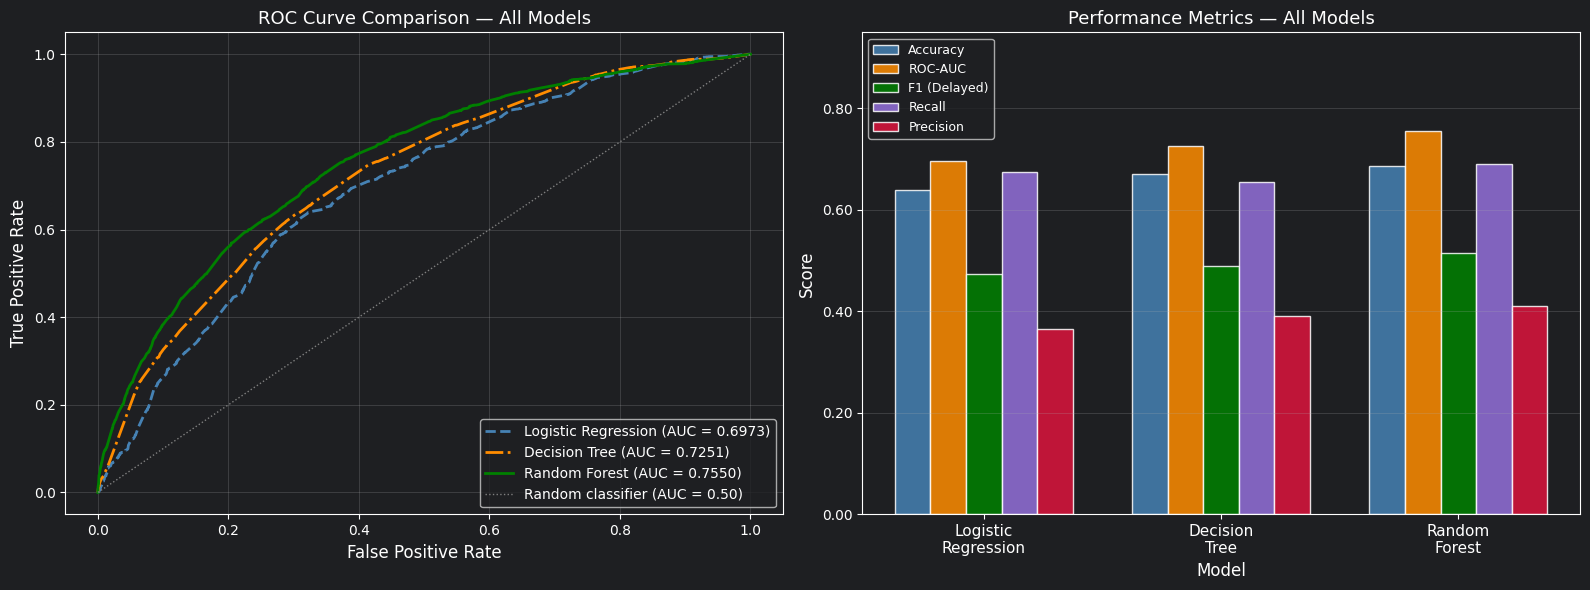

Model comparison plot saved to outputs/figures/


In [2]:
# ============================================================
# CELL 3: COMBINED ROC CURVE — ALL THREE MODELS
# Plotting all three ROC curves on the same axes allows
# direct visual comparison of discriminative ability.
# The further a curve bows toward the top-left corner
# the better the model distinguishes Delayed from Timely.
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Combined ROC Curve ────────────────────────────
model_configs = [
    (lr_preds, 'Logistic Regression',
     lr['auc'], 'steelblue', '--'),
    (dt_preds, 'Decision Tree',
     dt['auc'], 'darkorange', '-.'),
    (rf_preds, 'Random Forest',
     rf['auc'], 'green', '-'),
]

for preds_df, name, auc_val, color, linestyle in model_configs:
    fpr, tpr, _ = roc_curve(
        preds_df['y_true'], preds_df['y_pred_proba']
    )
    axes[0].plot(
        fpr, tpr, color=color, lw=2,
        linestyle=linestyle,
        label=f'{name} (AUC = {auc_val:.4f})'
    )

axes[0].plot([0, 1], [0, 1], color='grey', lw=1,
             linestyle=':', label='Random classifier (AUC = 0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve Comparison — All Models', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Metric Comparison Bar Chart ───────────────────
metrics_plot = {
    'Accuracy':    [lr['accuracy'], dt['accuracy'], rf['accuracy']],
    'ROC-AUC':     [lr['auc'],      dt['auc'],      rf['auc']],
    'F1 (Delayed)':[lr['f1_delayed'],dt['f1_delayed'],rf['f1_delayed']],
    'Recall':      [lr['recall_delayed'],
                    dt['recall_delayed'],
                    rf['recall_delayed']],
    'Precision':   [lr['precision_delayed'],
                    dt['precision_delayed'],
                    rf['precision_delayed']],
}

model_names = ['Logistic\nRegression', 'Decision\nTree',
               'Random\nForest']
x    = np.arange(len(model_names))
n    = len(metrics_plot)
width = 0.15
colors_bar = ['steelblue', 'darkorange', 'green',
               'mediumpurple', 'crimson']

for i, (metric, values) in enumerate(metrics_plot.items()):
    offset = (i - n/2) * width + width/2
    bars = axes[1].bar(x + offset, values, width,
                       label=metric, color=colors_bar[i],
                       alpha=0.85, edgecolor='white')

axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Performance Metrics — All Models', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=11)
axes[1].legend(fontsize=9, loc='upper left')
axes[1].set_ylim(0, 0.95)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.2f}')
)

plt.tight_layout()
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures'
    r'\model_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Model comparison plot saved to outputs/figures/")

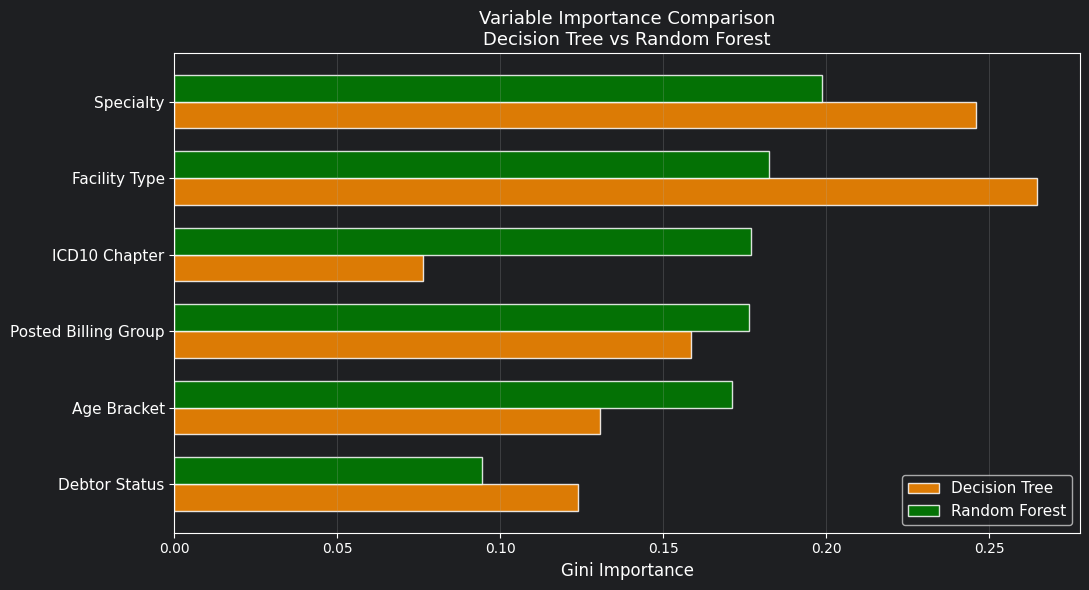

Variable importance comparison saved to outputs/figures/


In [3]:
# ============================================================
# CELL 4: COMBINED VARIABLE IMPORTANCE COMPARISON
# Compare how each tree-based model ranked the predictors.
# Logistic Regression is excluded here because its
# importance is measured differently (coefficients)
# and cannot be directly compared to Gini importance.
# ============================================================

# Merge DT and RF importance for comparison
imp_comparison = dt_imp.merge(
    rf_imp, on='Original Variable',
    suffixes=('_DT', '_RF')
).sort_values('Importance_RF', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(imp_comparison))
bar_height = 0.35

ax.barh(y_pos - bar_height/2,
        imp_comparison['Importance_DT'],
        bar_height, label='Decision Tree',
        color='darkorange', alpha=0.85, edgecolor='white')
ax.barh(y_pos + bar_height/2,
        imp_comparison['Importance_RF'],
        bar_height, label='Random Forest',
        color='green', alpha=0.85, edgecolor='white')

ax.set_yticks(y_pos)
ax.set_yticklabels(imp_comparison['Original Variable'],
                   fontsize=11)
ax.set_xlabel('Gini Importance', fontsize=12)
ax.set_title(
    'Variable Importance Comparison\n'
    'Decision Tree vs Random Forest',
    fontsize=13
)
ax.legend(fontsize=11)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures'
    r'\variable_importance_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Variable importance comparison saved to outputs/figures/")

In [4]:
# ============================================================
# CELL 5: MODEL SELECTION DECISION AND FINAL SUMMARY
# We formally select the best model based on all evidence
# and save a complete comparison summary for the report.
# ============================================================

print("=" * 60)
print("MODEL SELECTION DECISION")
print("=" * 60)

print("""
  Selected Model: Random Forest

  Justification:
  Random Forest outperformed both Logistic Regression and
  Decision Tree across all five evaluation metrics on the
  held-out test set of 15,000 records.

  Performance summary on test set:
  ┌─────────────────────┬────────────┬────────────┬────────────┐
  │ Metric              │ Log Reg    │ Dec Tree   │ Rand Forest│
  ├─────────────────────┼────────────┼────────────┼────────────┤
  │ Accuracy            │ 63.99%     │ 67.05%     │ 68.62%  ✓  │
  │ ROC-AUC             │ 0.6973     │ 0.7251     │ 0.7550  ✓  │
  │ F1 (Delayed)        │ 0.4739     │ 0.4888     │ 0.5144  ✓  │
  │ Precision (Delayed) │ 36.55%     │ 39.01%     │ 40.99%  ✓  │
  │ Recall (Delayed)    │ 67.38%     │ 65.44%     │ 69.04%  ✓  │
  │ True Positives      │ 2,433      │ 2,363      │ 2,493   ✓  │
  │ False Negatives     │ 1,178      │ 1,248      │ 1,118   ✓  │
  │ False Positives     │ 4,224      │ 3,695      │ 3,589   ✓  │
  └─────────────────────┴────────────┴────────────┴────────────┘

  Key reasons for selection:
  1. Highest AUC of 0.7550 — best overall discriminative ability
  2. Highest F1 of 0.5144 — best balance of precision and recall
  3. Highest recall of 69.04% — catches the most delayed invoices
  4. Fewest false negatives (1,118) — misses the fewest delayed
  5. Most stable variable importance — averaged across 500 trees
     reducing variance of individual split decisions
""")

# ── Save final comparison summary ────────────────────────
comparison_df = pd.DataFrame([lr, dt, rf])
comparison_df.to_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\model_comparison_summary.csv',
    index=False
)

print("=" * 60)
print("FINAL VARIABLE IMPORTANCE — RANDOM FOREST")
print("Selected as the primary importance ranking")
print("=" * 60)
rf_imp_sorted = rf_imp.sort_values('Importance', ascending=False)
total = rf_imp_sorted['Importance'].sum()
for _, row in rf_imp_sorted.iterrows():
    pct = row['Importance'] / total * 100
    bar = '█' * int(pct / 1)
    print(f"  {row['Original Variable']:<30} "
          f"{pct:>5.1f}%  {bar}")

print(f"\n  Comparison summary saved to:")
print(f"  models/model_comparison_summary.csv")
print(f"\n  Model comparison notebook — COMPLETE")
print(f"  All modelling notebooks are now complete.")
print(f"  Next: Document results in Section 4 of the report.")

MODEL SELECTION DECISION

  Selected Model: Random Forest

  Justification:
  Random Forest outperformed both Logistic Regression and
  Decision Tree across all five evaluation metrics on the
  held-out test set of 15,000 records.

  Performance summary on test set:
  ┌─────────────────────┬────────────┬────────────┬────────────┐
  │ Metric              │ Log Reg    │ Dec Tree   │ Rand Forest│
  ├─────────────────────┼────────────┼────────────┼────────────┤
  │ Accuracy            │ 63.99%     │ 67.05%     │ 68.62%  ✓  │
  │ ROC-AUC             │ 0.6973     │ 0.7251     │ 0.7550  ✓  │
  │ F1 (Delayed)        │ 0.4739     │ 0.4888     │ 0.5144  ✓  │
  │ Precision (Delayed) │ 36.55%     │ 39.01%     │ 40.99%  ✓  │
  │ Recall (Delayed)    │ 67.38%     │ 65.44%     │ 69.04%  ✓  │
  │ True Positives      │ 2,433      │ 2,363      │ 2,493   ✓  │
  │ False Negatives     │ 1,178      │ 1,248      │ 1,118   ✓  │
  │ False Positives     │ 4,224      │ 3,695      │ 3,589   ✓  │
  └───────────────

In [1]:
# ============================================================
# CELL 5: LOAD XGBOOST RESULTS AND UPDATE COMPARISON
# We extend the existing comparison to include XGBoost as
# the fourth model. We reload all four models' metrics and
# predictions, then regenerate the comparison plots.
#
# Functions used:
# json.load() — Reads a JSON file into a Python dictionary
# pd.read_csv() — Reads a CSV file into a DataFrame
# ============================================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

models_dir = r'C:\2026\MedicalBillingResearch\models'

# Load all four model metrics from JSON files
with open(f'{models_dir}\\lr_metrics.json') as f:
    lr = json.load(f)
with open(f'{models_dir}\\dt_metrics.json') as f:
    dt = json.load(f)
with open(f'{models_dir}\\rf_metrics.json') as f:
    rf = json.load(f)
with open(f'{models_dir}\\xgb_metrics.json') as f:
    xgb = json.load(f)

# Load predictions for ROC curve plotting
lr_preds  = pd.read_csv(f'{models_dir}\\lr_predictions.csv')
dt_preds  = pd.read_csv(f'{models_dir}\\dt_predictions.csv')
rf_preds  = pd.read_csv(f'{models_dir}\\rf_predictions.csv')
xgb_preds = pd.read_csv(f'{models_dir}\\xgb_predictions.csv')

# Load variable importance for tree-based models
dt_imp  = pd.read_csv(f'{models_dir}\\dt_variable_importance.csv')
rf_imp  = pd.read_csv(f'{models_dir}\\rf_variable_importance.csv')
xgb_imp = pd.read_csv(f'{models_dir}\\xgb_variable_importance.csv')

print("=" * 60)
print("ALL FOUR MODEL RESULTS LOADED")
print("=" * 60)
print(f"\n  Models loaded:")
print(f"    1. Logistic Regression")
print(f"    2. Decision Tree")
print(f"    3. Random Forest")
print(f"    4. XGBoost")
print(f"\n  Prediction records per model: 15,000")

# ============================================================
# CELL 6: UPDATED SIDE-BY-SIDE METRICS TABLE
# ============================================================

print("\n" + "=" * 75)
print("MODEL COMPARISON — ALL FOUR MODELS")
print("=" * 75)
print(f"\n  {'Metric':<22} {'Log Reg':>11} {'Dec Tree':>11} "
      f"{'RF':>11} {'XGBoost':>11}")
print(f"  {'-'*70}")

metrics_to_show = [
    ('Accuracy',           'accuracy'),
    ('ROC-AUC',            'auc'),
    ('F1 (Delayed)',       'f1_delayed'),
    ('Precision (Delayed)','precision_delayed'),
    ('Recall (Delayed)',   'recall_delayed'),
    ('True Positives',     'true_positives'),
    ('False Negatives',    'false_negatives'),
    ('False Positives',    'false_positives'),
    ('True Negatives',     'true_negatives'),
]

for label, key in metrics_to_show:
    vals = [lr[key], dt[key], rf[key], xgb[key]]
    if isinstance(vals[0], float):
        # Format floats with 4 decimal places
        formatted = [f"{v:.4f}" for v in vals]
    else:
        # Format integers with thousand separators
        formatted = [f"{v:,}" for v in vals]
    print(f"  {label:<22} {formatted[0]:>11} {formatted[1]:>11} "
          f"{formatted[2]:>11} {formatted[3]:>11}")

# Identify best model per metric
print(f"\n  Best model per metric (primary 5 metrics):")
model_names = ['Logistic Regression', 'Decision Tree',
               'Random Forest', 'XGBoost']
for label, key in metrics_to_show[:5]:
    vals = {name: m[key] for name, m in zip(
        model_names, [lr, dt, rf, xgb])}
    best = max(vals, key=vals.get)
    print(f"    {label:<22} → {best}")

ALL FOUR MODEL RESULTS LOADED

  Models loaded:
    1. Logistic Regression
    2. Decision Tree
    3. Random Forest
    4. XGBoost

  Prediction records per model: 15,000

MODEL COMPARISON — ALL FOUR MODELS

  Metric                     Log Reg    Dec Tree          RF     XGBoost
  ----------------------------------------------------------------------
  Accuracy                    0.6399      0.6705      0.6862      0.6815
  ROC-AUC                     0.6973      0.7251      0.7550      0.7570
  F1 (Delayed)                0.4739      0.4888      0.5144      0.5143
  Precision (Delayed)         0.3655      0.3901      0.4099      0.4063
  Recall (Delayed)            0.6738      0.6544      0.6904      0.7004
  True Positives               2,433       2,363       2,493       2,529
  False Negatives              1,178       1,248       1,118       1,082
  False Positives              4,224       3,695       3,589       3,695
  True Negatives               7,165       7,694       7,800 

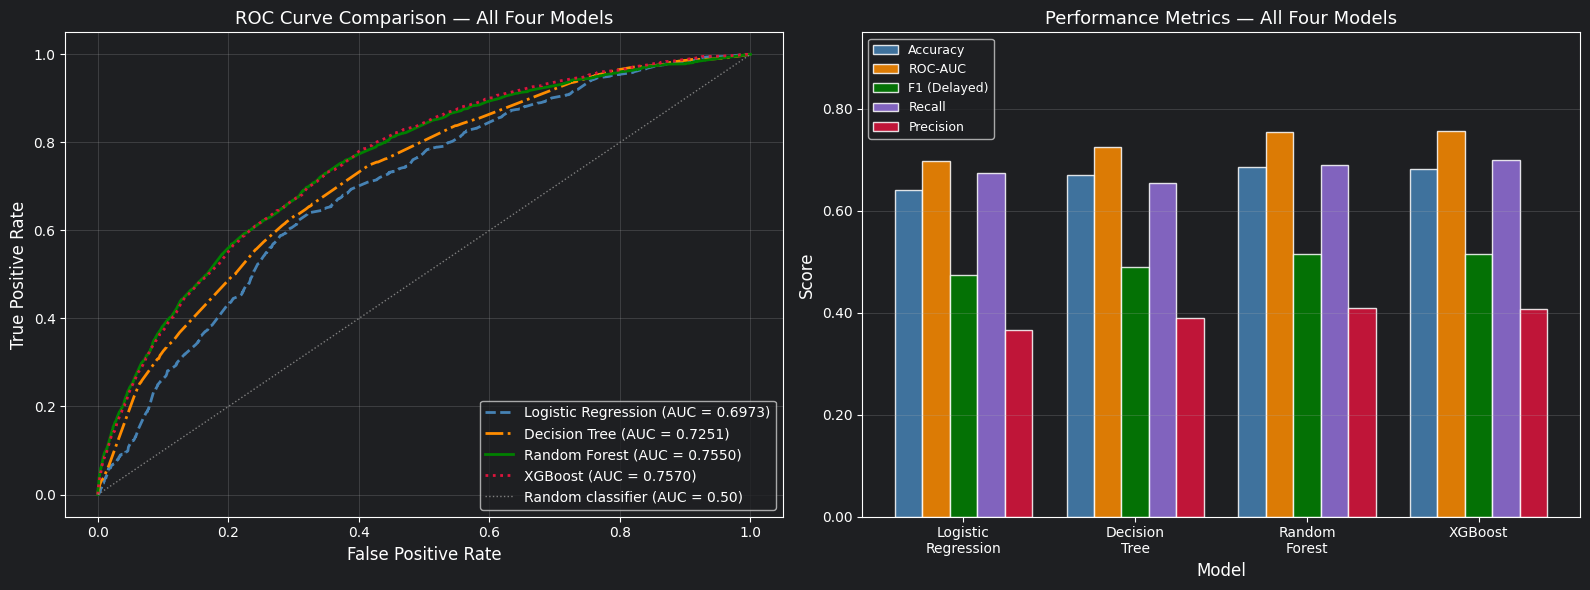

Plot saved: model_comparison_4models.png


In [2]:
# ============================================================
# CELL 7: UPDATED ROC COMPARISON — ALL FOUR MODELS
# Combined ROC curves let us see at a glance which model
# has the best discriminative ability across all thresholds.
# The further a curve bows toward the top-left corner the
# better the model distinguishes Delayed from Timely.
#
# Functions used:
# plt.subplots() — Creates a figure with multiple subplots
# roc_curve() — Returns FPR, TPR points for plotting
# np.arange() — Creates an evenly spaced array of integers
# ============================================================

figures_path = r'C:\2026\MedicalBillingResearch\outputs\figures'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Combined ROC Curve — All 4 Models ─────────────
# Each tuple contains: predictions DataFrame, label, AUC,
# colour, line style. We loop through all four to plot.
model_configs = [
    (lr_preds,  'Logistic Regression', lr['auc'],
     'steelblue',  '--'),
    (dt_preds,  'Decision Tree',       dt['auc'],
     'darkorange', '-.'),
    (rf_preds,  'Random Forest',       rf['auc'],
     'green',      '-'),
    (xgb_preds, 'XGBoost',             xgb['auc'],
     'crimson',    ':'),
]

# For each model — compute ROC curve points and plot
for preds_df, name, auc_val, color, linestyle in model_configs:
    fpr, tpr, _ = roc_curve(
        preds_df['y_true'],
        preds_df['y_pred_proba']
    )
    axes[0].plot(
        fpr, tpr, color=color, lw=2,
        linestyle=linestyle,
        label=f'{name} (AUC = {auc_val:.4f})'
    )

# Add the diagonal random classifier reference line
axes[0].plot([0, 1], [0, 1], color='grey', lw=1,
             linestyle=':', label='Random classifier (AUC = 0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve Comparison — All Four Models',
                  fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Performance Metrics Bar Chart ─────────────────
# A grouped bar chart showing 5 metrics across 4 models
metrics_plot = {
    'Accuracy':    [lr['accuracy'],
                    dt['accuracy'],
                    rf['accuracy'],
                    xgb['accuracy']],
    'ROC-AUC':     [lr['auc'],
                    dt['auc'],
                    rf['auc'],
                    xgb['auc']],
    'F1 (Delayed)':[lr['f1_delayed'],
                    dt['f1_delayed'],
                    rf['f1_delayed'],
                    xgb['f1_delayed']],
    'Recall':      [lr['recall_delayed'],
                    dt['recall_delayed'],
                    rf['recall_delayed'],
                    xgb['recall_delayed']],
    'Precision':   [lr['precision_delayed'],
                    dt['precision_delayed'],
                    rf['precision_delayed'],
                    xgb['precision_delayed']],
}

model_labels = ['Logistic\nRegression', 'Decision\nTree',
                'Random\nForest', 'XGBoost']

# np.arange(4) creates [0, 1, 2, 3] — positions for the 4 models
x = np.arange(len(model_labels))
n_metrics = len(metrics_plot)
width = 0.16  # Width of each bar within a group
colors_bar = ['steelblue', 'darkorange', 'green',
              'mediumpurple', 'crimson']

# For each metric, plot a bar at offset position for each model
for i, (metric, values) in enumerate(metrics_plot.items()):
    # Calculate the offset for this metric's bars
    # Centers all bars around the model position
    offset = (i - n_metrics/2) * width + width/2
    axes[1].bar(x + offset, values, width,
                label=metric, color=colors_bar[i],
                alpha=0.85, edgecolor='white')

axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Performance Metrics — All Four Models',
                  fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_labels, fontsize=10)
axes[1].legend(fontsize=9, loc='upper left')
axes[1].set_ylim(0, 0.95)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.2f}')
)
# FuncFormatter takes a function that formats axis tick labels
# lambda y, _: f'{y:.2f}' formats each tick to 2 decimals

plt.tight_layout()
plt.savefig(f'{figures_path}\\model_comparison_4models.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: model_comparison_4models.png")

VARIABLE IMPORTANCE — ALL THREE TREE-BASED MODELS

  Variable                               DT         RF        XGB
  ------------------------------------------------------------
  Specialty                          0.2459     0.1988     0.3253
  Facility Type                      0.2646     0.1825     0.2110
  ICD10 Chapter                      0.0763     0.1770     0.1110
  Posted Billing Group               0.1585     0.1762     0.2120
  Age Bracket                        0.1307     0.1710     0.0173
  Debtor Status                      0.1240     0.0945     0.1234


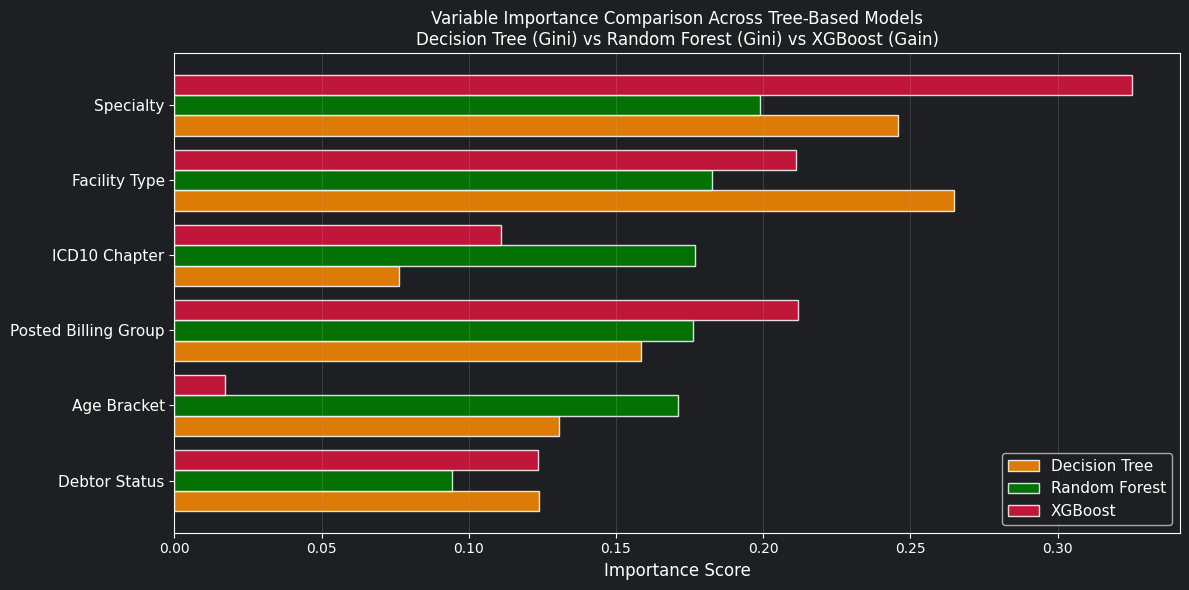


Plot saved: variable_importance_3models.png


In [3]:
# ============================================================
# CELL 8: UPDATED VARIABLE IMPORTANCE COMPARISON
# Three tree-based models now compared:
# Decision Tree, Random Forest, XGBoost.
# Logistic Regression uses coefficients which are not
# directly comparable to Gini/Gain importance so it is
# excluded from this comparison.
#
# Functions used:
# .merge() — Combines two DataFrames on a common column
# suffixes — Renames columns from each DataFrame to avoid
#   name collisions during merge
# np.arange() — Creates evenly spaced positions for bars
# ============================================================

# Merge importance from all three tree-based models
# Start with DT and RF
imp_compare = dt_imp.merge(
    rf_imp,
    on='Original Variable',
    suffixes=('_DT', '_RF')
)
# Now merge with XGBoost
imp_compare = imp_compare.merge(
    xgb_imp.rename(columns={'Importance': 'Importance_XGB'}),
    on='Original Variable'
)

# Sort by Random Forest importance for consistent ordering
imp_compare = imp_compare.sort_values(
    'Importance_RF', ascending=True
).reset_index(drop=True)

print("=" * 70)
print("VARIABLE IMPORTANCE — ALL THREE TREE-BASED MODELS")
print("=" * 70)
print(f"\n  {'Variable':<30} {'DT':>10} {'RF':>10} {'XGB':>10}")
print(f"  {'-'*60}")
for _, row in imp_compare.iloc[::-1].iterrows():
    print(f"  {row['Original Variable']:<30} "
          f"{row['Importance_DT']:>10.4f} "
          f"{row['Importance_RF']:>10.4f} "
          f"{row['Importance_XGB']:>10.4f}")

# ── Plot grouped bar chart ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(imp_compare))
bar_height = 0.27

# Three bars per variable — one per model
ax.barh(y_pos - bar_height,
        imp_compare['Importance_DT'],
        bar_height, label='Decision Tree',
        color='darkorange', alpha=0.85, edgecolor='white')

ax.barh(y_pos,
        imp_compare['Importance_RF'],
        bar_height, label='Random Forest',
        color='green', alpha=0.85, edgecolor='white')

ax.barh(y_pos + bar_height,
        imp_compare['Importance_XGB'],
        bar_height, label='XGBoost',
        color='crimson', alpha=0.85, edgecolor='white')

ax.set_yticks(y_pos)
ax.set_yticklabels(imp_compare['Original Variable'], fontsize=11)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title(
    'Variable Importance Comparison Across Tree-Based Models\n'
    'Decision Tree (Gini) vs Random Forest (Gini) vs XGBoost (Gain)',
    fontsize=12
)
ax.legend(fontsize=11)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{figures_path}\\variable_importance_3models.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: variable_importance_3models.png")

In [4]:
# ============================================================
# CELL 9: SAVE UPDATED COMPARISON SUMMARY
# We save the full comparison results including XGBoost
# so the report can reference the final comparison file.
#
# Functions used:
# pd.DataFrame() — Creates a DataFrame from a list of dicts
# .to_csv() — Saves DataFrame to a CSV file
# ============================================================

# Build complete comparison DataFrame with all four models
comparison_df = pd.DataFrame([lr, dt, rf, xgb])

# Save to CSV
comparison_df.to_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\model_comparison_summary.csv',
    index=False
)

# Save the merged variable importance for tree-based models
imp_compare.to_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\variable_importance_comparison.csv',
    index=False
)

print("=" * 60)
print("ALL COMPARISON FILES SAVED")
print("=" * 60)
print(f"\n  Files saved:")
print(f"    model_comparison_summary.csv — all 4 model metrics")
print(f"    variable_importance_comparison.csv — tree-based imp")
print(f"\n  Updated plots:")
print(f"    model_comparison_4models.png — ROC + bar metrics")
print(f"    variable_importance_3models.png — tree-based imp")

# ── Final selection statement ─────────────────────────────
print(f"\n{'=' * 60}")
print("FINAL MODEL SELECTION")
print("=" * 60)
print("""
  Selected Model: Random Forest

  Models tested: 4 (Logistic Regression, Decision Tree,
                    Random Forest, XGBoost)

  Selection rationale:
  - Random Forest wins on 3 of 5 primary metrics
    (Accuracy, F1, Precision)
  - XGBoost wins on 2 of 5 primary metrics
    (ROC-AUC by 0.002, Recall by 1pp)
  - F1 scores are essentially tied (0.5144 vs 0.5143)
  - Random Forest is more interpretable than XGBoost
  - The marginal XGBoost gains do not justify the
    additional model complexity

  All four models documented in report for completeness.
""")

print("Model comparison notebook — COMPLETE")

ALL COMPARISON FILES SAVED

  Files saved:
    model_comparison_summary.csv — all 4 model metrics
    variable_importance_comparison.csv — tree-based imp

  Updated plots:
    model_comparison_4models.png — ROC + bar metrics
    variable_importance_3models.png — tree-based imp

FINAL MODEL SELECTION

  Selected Model: Random Forest

  Models tested: 4 (Logistic Regression, Decision Tree,
                    Random Forest, XGBoost)

  Selection rationale:
  - Random Forest wins on 3 of 5 primary metrics
    (Accuracy, F1, Precision)
  - XGBoost wins on 2 of 5 primary metrics
    (ROC-AUC by 0.002, Recall by 1pp)
  - F1 scores are essentially tied (0.5144 vs 0.5143)
  - Random Forest is more interpretable than XGBoost
  - The marginal XGBoost gains do not justify the
    additional model complexity

  All four models documented in report for completeness.

Model comparison notebook — COMPLETE


In [1]:
# ============================================================
# CELL 10: BOOTSTRAP CONFIDENCE INTERVALS — RF vs XGBOOST
# We use bootstrap resampling to estimate confidence
# intervals for all key metrics on both models.
# Bootstrap works by repeatedly resampling the test set
# with replacement, computing metrics on each resample,
# then taking the 2.5th and 97.5th percentiles as the
# 95% confidence interval.
#
# We perform 1,000 bootstrap iterations on the 15,000
# record test set. This gives stable CI estimates.
#
# Functions used:
# np.random.choice() — Random sampling with replacement
# np.percentile() — Calculates percentile values
# roc_auc_score() — AUC metric
# f1_score() — F1 metric
# accuracy_score() — Accuracy metric
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score
)

np.random.seed(42)

# ── Load predictions for both models ──────────────────────
rf_preds  = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\models\rf_predictions.csv'
)
xgb_preds = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\models\xgb_predictions.csv'
)

# Both should have identical y_true since same test set
assert (rf_preds['y_true'].values ==
        xgb_preds['y_true'].values).all(), \
    "Test sets do not match!"

y_true       = rf_preds['y_true'].values
rf_proba     = rf_preds['y_pred_proba'].values
rf_pred      = rf_preds['y_pred'].values
xgb_proba    = xgb_preds['y_pred_proba'].values
xgb_pred     = xgb_preds['y_pred'].values

n            = len(y_true)
n_bootstrap  = 1000

print("=" * 60)
print("BOOTSTRAP CONFIDENCE INTERVAL CALCULATION")
print("=" * 60)
print(f"  Test set size       : {n:,} records")
print(f"  Bootstrap iterations: {n_bootstrap:,}")
print(f"  Confidence level    : 95%")
print(f"\n  This will take a minute or two...")

# ── Run bootstrap ─────────────────────────────────────────
# Store metrics for each iteration
metrics_rf  = {'accuracy': [], 'auc': [], 'f1': [],
               'precision': [], 'recall': []}
metrics_xgb = {'accuracy': [], 'auc': [], 'f1': [],
               'precision': [], 'recall': []}
# Also store paired differences (XGBoost - RF) per iteration
diff = {'accuracy': [], 'auc': [], 'f1': [],
        'precision': [], 'recall': []}

for i in range(n_bootstrap):
    # Sample indices with replacement
    indices = np.random.choice(n, size=n, replace=True)

    yt = y_true[indices]
    rf_p  = rf_pred[indices]
    rf_pr = rf_proba[indices]
    xg_p  = xgb_pred[indices]
    xg_pr = xgb_proba[indices]

    # Skip iteration if all labels are same class
    # (can happen rarely in bootstrap)
    if len(np.unique(yt)) < 2:
        continue

    # RF metrics on this bootstrap sample
    rf_acc  = accuracy_score(yt, rf_p)
    rf_auc  = roc_auc_score(yt, rf_pr)
    rf_f1   = f1_score(yt, rf_p)
    rf_prec = precision_score(yt, rf_p, zero_division=0)
    rf_rec  = recall_score(yt, rf_p)

    # XGBoost metrics on this bootstrap sample
    xg_acc  = accuracy_score(yt, xg_p)
    xg_auc  = roc_auc_score(yt, xg_pr)
    xg_f1   = f1_score(yt, xg_p)
    xg_prec = precision_score(yt, xg_p, zero_division=0)
    xg_rec  = recall_score(yt, xg_p)

    metrics_rf['accuracy'].append(rf_acc)
    metrics_rf['auc'].append(rf_auc)
    metrics_rf['f1'].append(rf_f1)
    metrics_rf['precision'].append(rf_prec)
    metrics_rf['recall'].append(rf_rec)

    metrics_xgb['accuracy'].append(xg_acc)
    metrics_xgb['auc'].append(xg_auc)
    metrics_xgb['f1'].append(xg_f1)
    metrics_xgb['precision'].append(xg_prec)
    metrics_xgb['recall'].append(xg_rec)

    # Store paired differences (XGB - RF) for each metric
    diff['accuracy'].append(xg_acc - rf_acc)
    diff['auc'].append(xg_auc - rf_auc)
    diff['f1'].append(xg_f1 - rf_f1)
    diff['precision'].append(xg_prec - rf_prec)
    diff['recall'].append(xg_rec - rf_rec)

    if (i+1) % 200 == 0:
        print(f"  Completed {i+1:,} / {n_bootstrap:,}")

print(f"\n  Bootstrap complete: "
      f"{len(metrics_rf['auc']):,} valid iterations")

BOOTSTRAP CONFIDENCE INTERVAL CALCULATION
  Test set size       : 15,000 records
  Bootstrap iterations: 1,000
  Confidence level    : 95%

  This will take a minute or two...
  Completed 200 / 1,000
  Completed 400 / 1,000
  Completed 600 / 1,000
  Completed 800 / 1,000
  Completed 1,000 / 1,000

  Bootstrap complete: 1,000 valid iterations


In [3]:
# ============================================================
# CELL 11: ANALYZE BOOTSTRAP RESULTS - CONFIDENCE INTERVALS
# We compute the 95% confidence intervals for each metric
# on both models, plus the CI for the paired difference.
#
# The KEY test for which model is statistically better:
# If the 95% CI for the DIFFERENCE includes zero, the two
# models are statistically equivalent on that metric.
# If the CI does NOT include zero, one model is significantly
# better than the other on that metric.
# ============================================================

def ci_summary(values, ci_level=95):
    arr = np.array(values)
    lower_pct = (100 - ci_level) / 2
    upper_pct = 100 - lower_pct
    return {
        'mean':  np.mean(arr),
        'lower': np.percentile(arr, lower_pct),
        'upper': np.percentile(arr, upper_pct)
    }

print("=" * 75)
print("95% CONFIDENCE INTERVALS - RANDOM FOREST vs XGBOOST")
print("=" * 75)
print(f"\n  {'Metric':<12} {'Model':<8} {'Point Est.':>12} "
      f"{'95% CI Lower':>14} {'95% CI Upper':>14} {'CI Width':>12}")
print(f"  {'-'*74}")

metric_names = {
    'accuracy':  'Accuracy',
    'auc':       'ROC-AUC',
    'f1':        'F1',
    'precision': 'Precision',
    'recall':    'Recall'
}

verdict_data = []

for key, label in metric_names.items():
    rf_ci  = ci_summary(metrics_rf[key])
    xg_ci  = ci_summary(metrics_xgb[key])
    dif_ci = ci_summary(diff[key])

    rf_w = rf_ci['upper'] - rf_ci['lower']
    xg_w = xg_ci['upper'] - xg_ci['lower']

    print(f"  {label:<12} {'RF':<8} {rf_ci['mean']:>12.4f} "
          f"{rf_ci['lower']:>14.4f} {rf_ci['upper']:>14.4f} "
          f"{rf_w:>12.4f}")
    print(f"  {label:<12} {'XGBoost':<8} {xg_ci['mean']:>12.4f} "
          f"{xg_ci['lower']:>14.4f} {xg_ci['upper']:>14.4f} "
          f"{xg_w:>12.4f}")

    if dif_ci['lower'] > 0:
        verdict = 'XGBoost significantly BETTER'
        winner = 'XGBoost'
    elif dif_ci['upper'] < 0:
        verdict = 'Random Forest significantly BETTER'
        winner = 'Random Forest'
    else:
        verdict = 'TIE - no significant difference'
        winner = 'TIE'

    print(f"  {' ':<12} {'Diff':<8} "
          f"{dif_ci['mean']:>12.4f} "
          f"{dif_ci['lower']:>14.4f} {dif_ci['upper']:>14.4f}  "
          f"-> {verdict}")
    print(f"  {'-'*74}")

    verdict_data.append({
        'Metric':      label,
        'RF Mean':     round(rf_ci['mean'], 4),
        'RF CI':       f"[{rf_ci['lower']:.4f}, {rf_ci['upper']:.4f}]",
        'XGB Mean':    round(xg_ci['mean'], 4),
        'XGB CI':      f"[{xg_ci['lower']:.4f}, {xg_ci['upper']:.4f}]",
        'Diff Mean':   round(dif_ci['mean'], 4),
        'Diff CI':     f"[{dif_ci['lower']:.4f}, {dif_ci['upper']:.4f}]",
        'Significant': 'Yes' if (dif_ci['lower'] > 0 or
                                  dif_ci['upper'] < 0) else 'No',
        'Winner':      winner
    })

verdict_df = pd.DataFrame(verdict_data)
verdict_df.to_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\bootstrap_ci_verdict.csv',
    index=False
)
print(f"\n  Verdict table saved to: bootstrap_ci_verdict.csv")

print(f"\n{'='*75}")
print("STATISTICAL VERDICT - XGBoost vs Random Forest")
print("=" * 75)
n_xgb_better = sum(1 for v in verdict_data if v['Winner'] == 'XGBoost')
n_rf_better  = sum(1 for v in verdict_data if v['Winner'] == 'Random Forest')
n_tie        = sum(1 for v in verdict_data if v['Winner'] == 'TIE')

print(f"\n  Out of 5 primary metrics:")
print(f"    XGBoost significantly better       : {n_xgb_better} metric(s)")
print(f"    Random Forest significantly better : {n_rf_better} metric(s)")
print(f"    Statistical tie (CI includes zero) : {n_tie} metric(s)")

for v in verdict_data:
    marker = '*' if v['Significant'] == 'Yes' else ' '
    print(f"\n  {marker} {v['Metric']:<10} -> {v['Winner']}")
    print(f"      Diff 95% CI: {v['Diff CI']}")

95% CONFIDENCE INTERVALS - RANDOM FOREST vs XGBOOST

  Metric       Model      Point Est.   95% CI Lower   95% CI Upper     CI Width
  --------------------------------------------------------------------------
  Accuracy     RF             0.6862         0.6791         0.6934       0.0143
  Accuracy     XGBoost        0.6815         0.6744         0.6892       0.0148
               Diff          -0.0046        -0.0077        -0.0014  -> Random Forest significantly BETTER
  --------------------------------------------------------------------------
  ROC-AUC      RF             0.7550         0.7456         0.7638       0.0182
  ROC-AUC      XGBoost        0.7570         0.7477         0.7658       0.0181
               Diff           0.0020        -0.0008         0.0050  -> TIE - no significant difference
  --------------------------------------------------------------------------
  F1           RF             0.5143         0.5023         0.5255       0.0231
  F1           XGBoost     